<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/MBE_project_case5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Case 5: Combination Drive — Gas Cap + Water Influx
# F = N·Eo + N·m·Eg + We
# Using Pot Aquifer: We = K·ΔP
# So: F = N·Eo + (Nm)·Eg + K·ΔP → Solve using Multiple Linear Regression

Pi = 4000
Bti = 1.550
Bgi = 0.00080

data = pd.DataFrame({
    'P':  [4000, 3800, 3600, 3400, 3200, 3000, 2800, 2600],
    'Bt': [1.550, 1.580, 1.620, 1.670, 1.735, 1.815, 1.910, 2.025],
    'Bg': [0.00080, 0.00083, 0.00087, 0.00092, 0.00098, 0.00106, 0.00116, 0.00129],
    'F':  [0, 2.55e6, 5.62e6, 9.05e6, 13.40e6, 18.25e6, 24.50e6, 31.80e6]  # bbl
})
data

,P,Bt,Bg,F
0,4000,1.550,0.00080,0.0
1,3800,1.580,0.00083,2550000.0
2,3600,1.620,0.00087,5620000.0
3,3400,1.670,0.00092,9050000.0
4,3200,1.735,0.00098,13400000.0
5,3000,1.815,0.00106,18250000.0
6,2800,1.910,0.00116,24500000.0
7,2600,2.025,0.00129,31800000.0


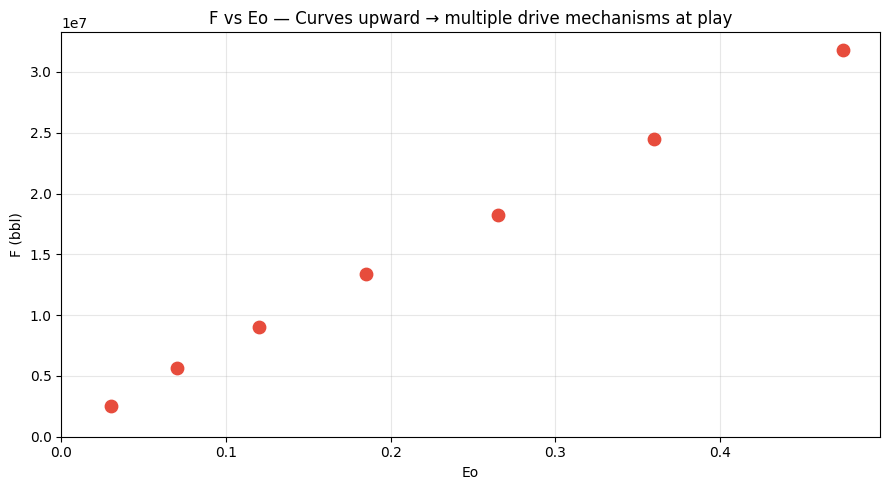

F vs Eo is NOT a straight line → simple depletion drive model is wrong
Upward curvature suggests gas cap expansion + water influx


In [ ]:
mask = data['F'] > 0

data['dP'] = Pi - data['P']
data['Eo'] = data['Bt'] - Bti
data['Eg'] = Bti * (data['Bg'] / Bgi - 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(data.loc[mask, 'Eo'], data.loc[mask, 'F'], c='#e74c3c', s=80, zorder=5)
ax.set_xlabel('Eo'); ax.set_ylabel('F (bbl)')
ax.set_title('F vs Eo — Curves upward → multiple drive mechanisms at play')
ax.set_xlim(0); ax.set_ylim(0); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("F vs Eo is NOT a straight line → simple depletion drive model is wrong")
print("Upward curvature suggests gas cap expansion + water influx")

In [ ]:
# F = N·Eo + (Nm)·Eg + K·dP
# This is a linear system: F = [Eo, Eg, dP] · [N, Nm, K]^T

Eo = data.loc[mask, 'Eo'].values
Eg = data.loc[mask, 'Eg'].values
dP = data.loc[mask, 'dP'].values
F  = data.loc[mask, 'F'].values

A = np.column_stack([Eo, Eg, dP])
result, residuals, _, _ = np.linalg.lstsq(A, F, rcond=None)

N, Nm, K = result
m = Nm / N

print(f"N = {N/1e6:.2f} MMSTB")
print(f"m = {m:.2f}")
print(f"K = {K:.0f} bbl/psi")

# Verify fit
F_calc = A @ result
r2 = 1 - np.sum((F - F_calc)**2) / np.sum((F - F.mean())**2)
print(f"R² = {r2:.6f}")

N = 18.68 MMSTB
m = 0.90
K = 4935 bbl/psi
R² = 0.999930


   P  DDI (Oil %)  SDI (Gas Cap %)  WDI (Water %)  Total %
3800         22.0             38.5           38.7     99.2
3600         23.3             40.7           35.1     99.1
3400         24.8             43.4           32.7    100.9
3200         25.8             43.9           29.5     99.2
3000         27.1             46.6           27.0    100.8
2800         27.5             48.1           24.2     99.7
2600         27.9             50.4           21.7    100.0


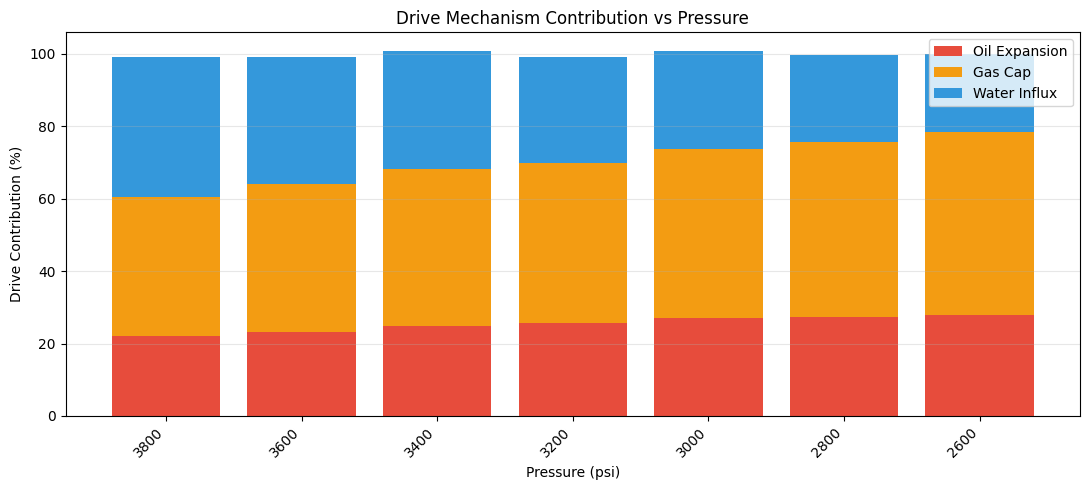

In [ ]:
# How much each mechanism contributes to total production
DDI = N * Eo / F           # Depletion Drive (oil expansion)
SDI = Nm * Eg / F          # Segregation Drive (gas cap)
WDI = K * dP / F           # Water Drive (aquifer)

drive = pd.DataFrame({
    'P': data.loc[mask, 'P'].values,
    'DDI (Oil %)': (DDI * 100).round(1),
    'SDI (Gas Cap %)': (SDI * 100).round(1),
    'WDI (Water %)': (WDI * 100).round(1),
    'Total %': ((DDI + SDI + WDI) * 100).round(1)
})
print(drive.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(dP))
ax.bar(x, DDI*100, label='Oil Expansion', color='#e74c3c')
ax.bar(x, SDI*100, bottom=DDI*100, label='Gas Cap', color='#f39c12')
ax.bar(x, WDI*100, bottom=(DDI+SDI)*100, label='Water Influx', color='#3498db')
ax.set_xticks(x)
ax.set_xticklabels([f'{p:.0f}' for p in data.loc[mask, 'P']], rotation=45, ha='right')
ax.set_xlabel('Pressure (psi)'); ax.set_ylabel('Drive Contribution (%)')
ax.set_title('Drive Mechanism Contribution vs Pressure')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()